<a href="https://colab.research.google.com/github/Gabrielmtztt/ConnectaTel-analysis/blob/main/ConnectaTel_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:

# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:

# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print("Cantidad de nulos en USERS:")
display(users.isna().sum())

print("\nProporción de nulos en USERS (%):")
display(users.isna().mean() * 100)

Cantidad de nulos en USERS:


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


Proporción de nulos en USERS (%):


user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64

In [ ]:
# cantidad de nulos para usage

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

DF USERS
--La columna CITY tiene 11.7% de valores nulos, esta proporcion es moderada por lo que se procederá a imputar los valores nulos con "Unknown" de esta manera se logra mantener la integridad de los 4000 usauarios y asi mismo se evitan los sesgos una vez que se realice el análisis geografico.

--En cuanto a la columna CHURN_DATE, esta columna indica la fecha de abandono de lso clientes, sin embargo, los valores nulos son validos ya que son datos de comportamiento real y representan usuarios activos, por este motivo no se deben imputar o eliminar.

DF USAGE
Se encontró que en la columna DATE hay 50 registros de un total de 4000 que son valores nulos, esto representa 0.125% y or ser tan bajo creo viable eliminar estas filas debido a que sin fecha no es posible asingar el consumo a un mes especifico para analisis posteriores.

Columnas DURATION y LENGTH, contienen 55% y 45% de valores faltantes. En este caso hay que tomar en cuenta que si el registro en TYPE es CALL la columna LENGTH será NaN y viceversa, esto es coherente con el tipo de actividad y por tal razon no creo que se requiera imputacion. Ademas, si se observa que la suma de los valores nulos en DURATION y LENGTH es consistente con el total de filas del dataset, se puede confirmar que no hay perdida de informacion si no que las metricas se dividen segun el tipo de servicio.




### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())
print(f"\nEdades únicas: {sorted(users['age'].unique())}")

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Edades únicas: [-999, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- En la columna USER_ID no se detectó ninguna anomalia, y esto se confirma con COUNT, 4000 registros, si miramos la diferencia entre el valor minimo y el maximo la diferencia entre ambos es precisamente 4000, lo cual confirma que cada registro de USER_ID es unico.
  
- La columna `age`:
- Se detectó un valor sentilen (-999) en la columna AGE, lo cual es una edad imposible y distorsiona el promedio y la desviacion estandar. En este caso se debe indentificar cuantos registros contienen este mismo valor y se deben reemplazar por NaN o por la mediana de las edades para que no haya sesgo en analisis posteriores

In [ ]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id', 'duration', 'length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- El conteo de las columnas ID y USER_ID de 40,000 en las dos confirma que no hay valores nulos en los identificadores. el rango de ID de 1 a 40,000 indica que cada registro tiene un identificados unico por lo que no es necesario tomar ninguna accion.

In [ ]:


# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


for col in columnas_user:
    print(f"\n--- Valores únicos en {col} ---")
    print(users[col].unique())
    print(f"Cantidad de valores únicos: {users[col].nunique()}")





--- Valores únicos en city ---
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Cantidad de valores únicos: 7

--- Valores únicos en plan ---
['Basico' 'Premium']
Cantidad de valores únicos: 2


In [ ]:

# explorar columna categórica de usage

print("Valores únicos en 'type':")
print(usage['type'].unique())
print(f"Cantidad de valores únicos: {usage['type'].nunique()}")



Valores únicos en 'type':
['call' 'text']
Cantidad de valores únicos: 2


- La columna `type`
-
- Al explorar los valores de la columna TYPE, se confirma que solo tiene las categorías 'call' y 'text'. No se detectaron valores atípicos (sentinels), errores de escritura (typos) ni valores nulos, por lo tanto no requiere ninguna acción de limpieza.




---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

- En la columna CITY  se encontraron valores sentinels (?) y nulos (Nan), lo cual significa datos faltantes en la ubicacion geografica de los usuarios.
- ¿Qué acción tomarías?
- Se deben reemplazar los valores "?" y "Nan" por "UNKNOWN" para mantener la consistencia y no perder registros.

En la columna PLAN no se hayaron inconsistencias y no requiere ninguna accion.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:


# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código



In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Distribucion de años en 'reg_date':")
print (users['reg_date'].dt.year.value_counts().sort_index())


Distribucion de años en 'reg_date':
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

Se observó que hay un salto en la cronologia de los regitros. hay una ausencia total de registros con el año 2025, estos pasan de 2024 a 2026. Dado que el periodo de estudio está definido hasta el 2024, los registros de 2026 se trataran como outliers y se excluiran del analisis para evitar sesgos.


In [ ]:
# Revisar los años presentes en `date` de usage
print("Distribucion de años en 'usage':")
print(usage['date'].dt.year.value_counts().sort_index())


Distribucion de años en 'usage':
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Una vez que se realizó el conteo de años, se confirma que el totoal de los registros corresponde al año 2024. A diferencia de la columna USERS. No se reuqieren mas acciones ya que todos los datos se encuentran dentro del rango definido en el proyecto.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
Se identificaron 40 registros en USERS (REG_DATE). Considerando que el periodo de estudio definido finaliza en 2024, esos resitros se clasifican como datos futuros o errores de captura. Se debera filtrar el dataset para excluir los registros que no esten en el rango de tiempo delimitado, de esta manera se puede asegurar que el analisis de retencion se base en datos historicos validos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print("Valores nulos en 'city' despues de limpieza:")
print(users['city'].isna().sum())
print(users['city'].value_counts(dropna=False).head())


Valores nulos en 'city' despues de limpieza:
565
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios

print("Conteo de nulos en 'reg_date':", users['reg_date'].isna().sum())

Conteo de nulos en 'reg_date': 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
mar_check = usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())
print("Proporción de nulos en 'duration' por tipo de servicio:")
print(mar_check)

Proporción de nulos en 'duration' por tipo de servicio:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
mar_check_length = usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

print("Proporción de nulos en 'length' por tipo de servicio:")
print(mar_check_length)

Proporción de nulos en 'length' por tipo de servicio:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Una vez que se analizó  la proporción de valores nulos, se concluye que la falta de información en duration y length es MAR (Missing At Random) y depende estrictamente de la variable TYPE. Existe una correlación inversa, los registros de tipo CALL estan completos en DURATION, pero tienen nulos en LENGTH. Al contrario de los registros de tipo TEXT tienen integridad del 100% en LENGTH, pero tienen nulos en DURATION.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call",  "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
print(usage_agg.head(3))

   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74


In [ ]:
# Renombrar columnas
usage_agg =usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
print(usage_agg.head(3))

   user_id  cant_mensajes  cant_llamadas  cant_minutos_llamada
0    10000              7              3                 23.70
1    10001              5             10                 33.18
2    10002              5              2                 10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# mostrar resultado
print(user_profile.head(5))

   user_id first_name last_name   age      city                      reg_date  \
0    10000     Carlos    Garcia  38.0  Medellín 2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres  53.0      <NA> 2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez  57.0      CDMX 2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez  69.0    Bogotá 2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres  63.0       GDL 2022-01-02 02:17:11.657914478   

      plan churn_date  cant_mensajes  cant_llamadas  cant_minutos_llamada  
0   Basico        NaN            7.0            3.0                 23.70  
1   Basico        NaN            5.0           10.0                 33.18  
2   Basico        NaN            5.0            2.0                 10.74  
3  Premium        NaN           11.0            3.0                  8.99  
4   Basico        NaN            4.0            3.0                  8.01  


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print(user_profile[columnas_numericas].describe())


               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [ ]:
# Distribución porcentual del tipo de plan
distribucion_plan = user_profile['plan'].value_counts(normalize=True)
print("Distribucion de planes en porcentaje:")
print(distribucion_plan)


Distribucion de planes en porcentaje:
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

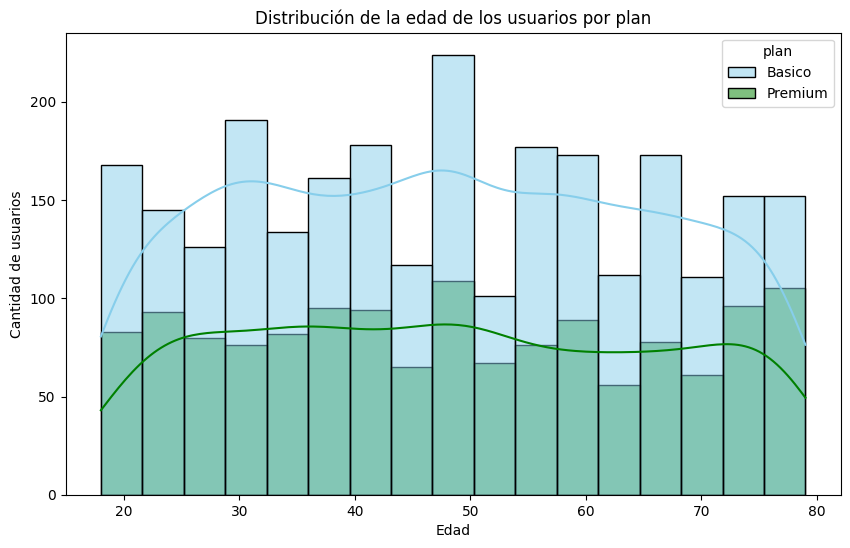

In [ ]:
# Histograma para visualizar la edad (age)

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la edad de los usuarios por plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights:
- Al observar la distribución de la edad por plan, se deduce que los usuarios están distribuidos en general equitativamente desde los 18 hasta los 80 años. Esto sugiere que el producto tiene un mercado amplio y no depende de segmentos por edad. En cuanto al comportamiento, ambos planes, Basico y Premium son similares. Ambos planes atraen usuarios de todoas las edades en cantidades similares.

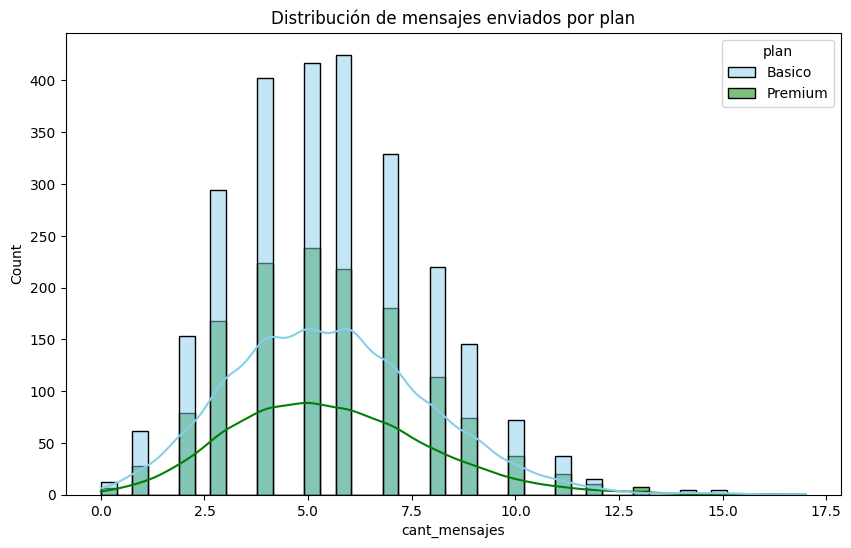

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de mensajes enviados por plan')
plt.show()

💡Insights:
- los usuarios de ambos planes se comportan de forma similar. El grupo Básico tiene más usuarios, por lo que las barras son más altas. La mayoría de los usuarios, tanto en Básico como en Premium envían entre 4 y 6 mensajes al mes. Hay un ligero sesgo a la derecha que indica que unos pocos usuarios tiene consumos mas intensivos con mas de 10 mensajes, pero son la minoría.

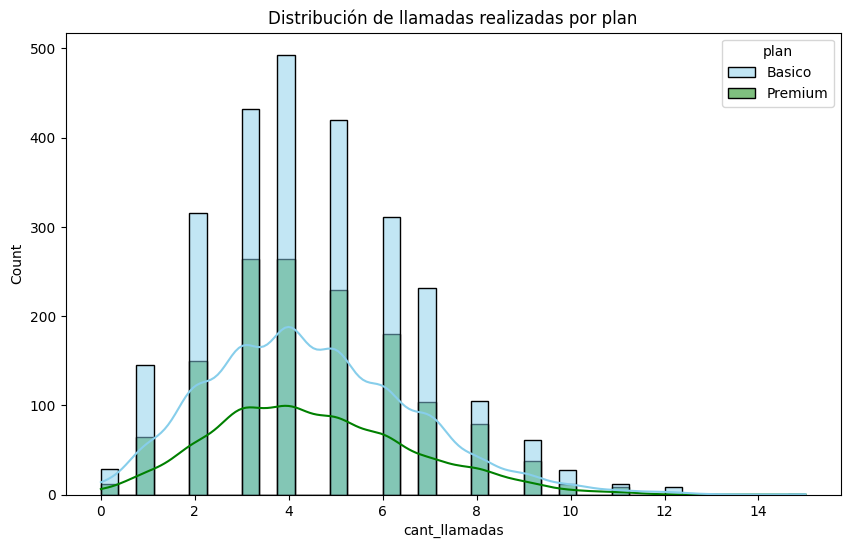

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de llamadas realizadas por plan')
plt.show()

💡Insights:
- Al igual que con los usuarios de mensajes, se detecta un ligero sesgo a la derecha alrededor de 4 llamadas, con una cola que se extiende hacia valores de entre 13 y 14 llamadas, esto nos indica que aunque la mayoria de usuarios tienen un comportamiento estandar, tenemos un grupo de usuarios quee realiza una cantidad mayor de llamadas. tambien se deduce del grafico que el tipo de plan no parece influir en la frecuencia de llamadas ya que se aprecian muy similares.

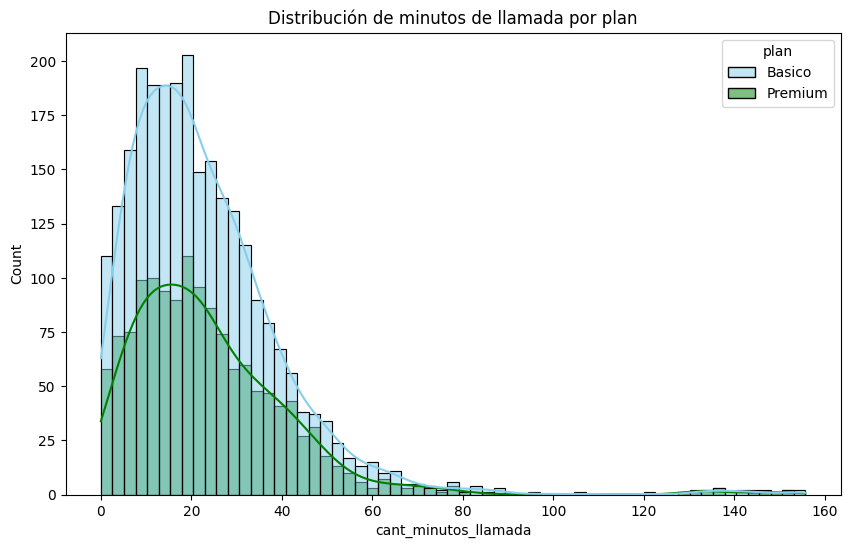

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de minutos de llamada por plan')
plt.show()

💡Insights:
- De acuerdo a la grafica Distribución de minutos de llamada por plan, podemos deducir qeu la gran mayoria de usuaris consume entre 10 y 30 minutos al mes, sin embargo tambien se aprecia un sesgo mas pronunicado que se xtiende hasta casi los 160 minutos. Con esto podemos conluir que se cuenta con una pequela cantidad de usuarios que consumen mas de 100 minutos y por lo tanto son de alto valor.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

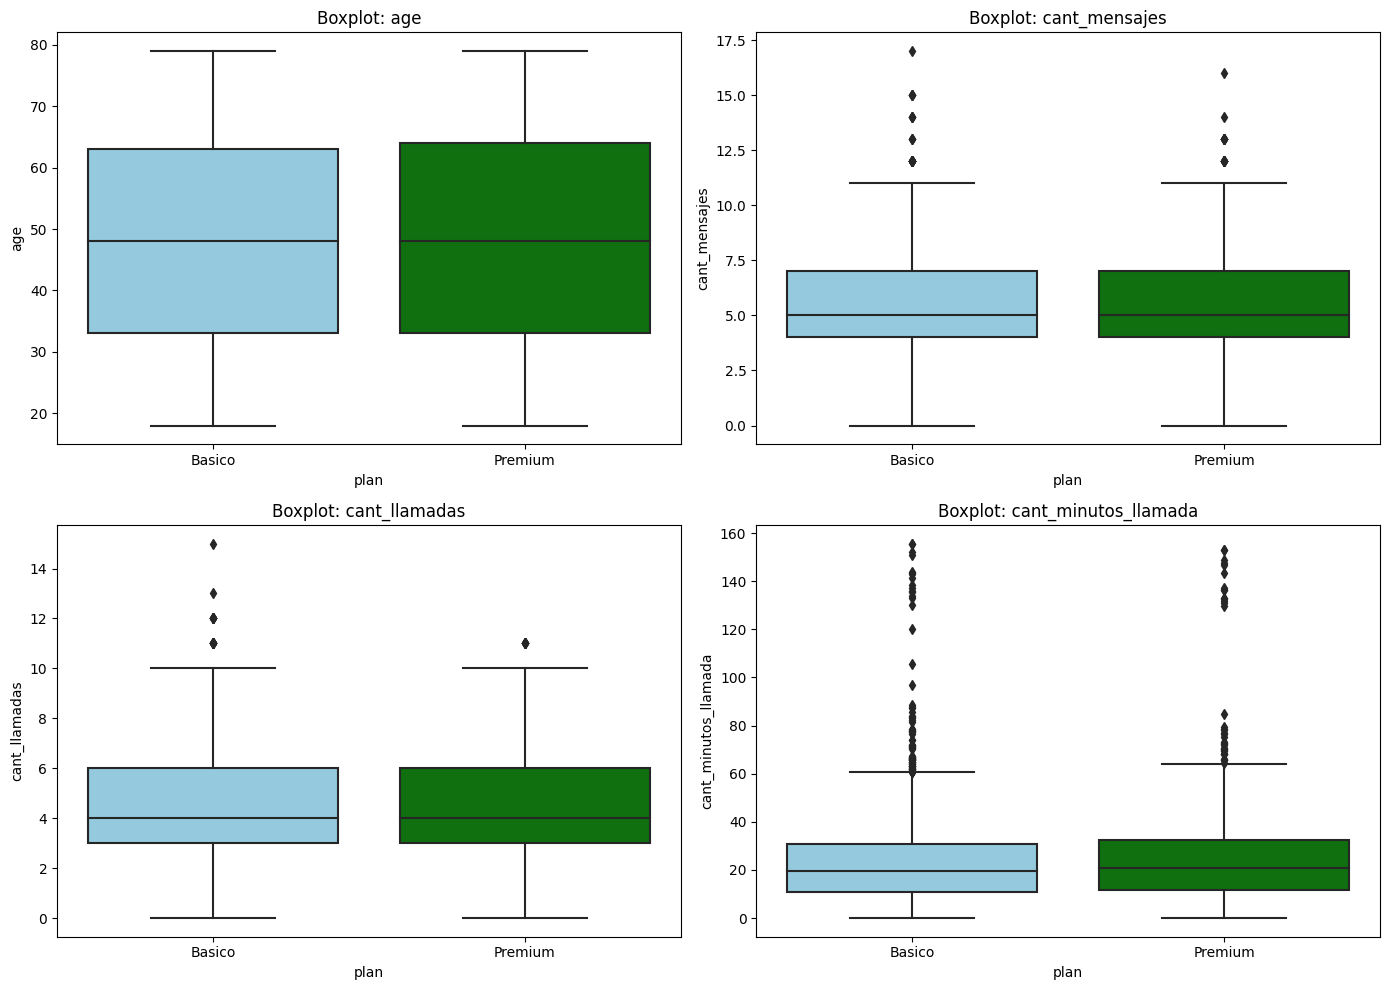

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

plt.figure(figsize=(14, 10))
for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2,2, i)
    sns.boxplot(data=user_profile, x ='plan', y=col, palette=['skyblue', 'green'])
    plt.title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()


💡Insights:
- Age: ...(presenta o no outliers)
- La población está bien equilibrada y la distribucion se ve limpia de outliers.

- cant_mensajes:
- Presenta algunos outliers en la parte superior, pero son pocos y similares en amabos planes, lo que simplemetne indica que son usuarios con un uso mas intensivo de lo normal.


- cant_llamadas:
Al igual que en el caso de cantidad de mensajes, tambien presenta algunos oultiers, pero no representan una anomalia que requiera ningunua accion por la naturaleza del servicio que estamos midiendo.

- cant_minutos_llamada:
- En el caso de cant_minutos_llamada, se aprecia un numero significativo de outliers, pero no son un error en los datos sino clientes de uso intensivo, y los mas propensos a cambiar a un plan que ofrezca mas datos, minutos etc.

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

#   Calculamos los cuartiles y el rango intercuartílico
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

   # Define el limite superor
    limite_superior = Q3 + 1.5 * IQR

    # Identifica cuantos usuarios sobrepasan el limite
    outliers = user_profile[user_profile[col] > limite_superior]

    print(f"Columna '{col}': Límite superior = {limite_superior:.2f} | Outliers encontrados = {len(outliers)}")


Columna 'cant_mensajes': Límite superior = 11.50 | Outliers encontrados = 46
Columna 'cant_llamadas': Límite superior = 10.50 | Outliers encontrados = 30
Columna 'cant_minutos_llamada': Límite superior = 61.86 | Outliers encontrados = 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- Se deben mantener porque no hay evidencia de errores de sistema como mensajes negativos o números con valores demasiado altos.eliminar estos datos representaria ignorar usuarios que dan preferencia al servicio de mensajeria y esto repercutiria en la precision de los promedios.
-
- cant_llamadas: mantener o no outliers, porqué?
- Se deben mantener porque el limite superior es de 10.5 y el máximo es 15. Esta pequeña diferencia indica que son casos de uso intensivo pero dentro de un rango lógico.
-
- cant_minutos_llamada: mantener o no outliers, porqué?
- Se deben mantener porque eliminar estos datos seria un error ya que borraría la informacion de los clientes que más ingresos o consumo generan. Estos clientes son potencialmente mas propensos a aumentar su plan y generar ingresos importantes.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

# Aplicar la función
user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

# Mostrar la distribución
print(user_profile['grupo_uso'].value_counts())



Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(edad):
    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

# Mostar la distribución
print(user_profile['grupo_edad'].value_counts())


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

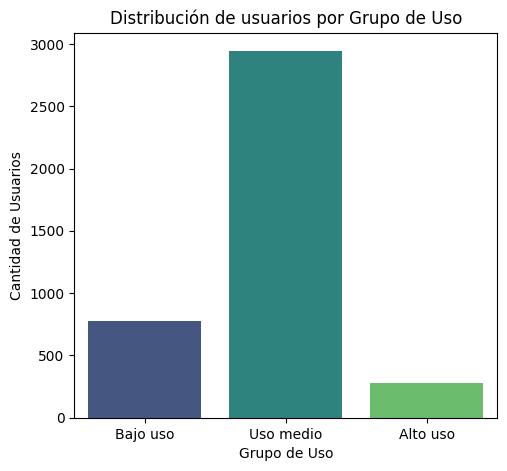

In [ ]:
# Visualización de los segmentos por uso
plt.figure(figsize=(12, 5))

# Segmentos por uso
plt.subplot(1, 2, 1)
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()

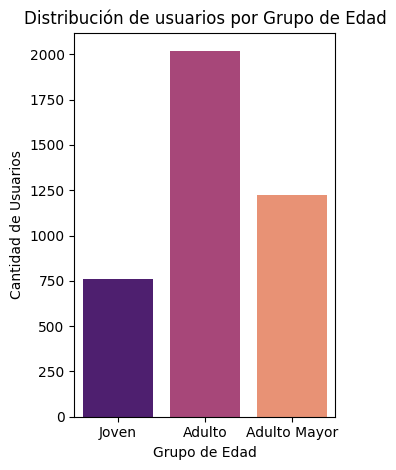

In [ ]:
# Visualización de los segmentos por edad
plt.subplot(1, 2, 2)
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.tight_layout()
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
El dataset original presentaba inconsistencias típicas de integración, principalmente en el formato de fechas y valores nulos. tambien se detectaron inconsistencias de formato y datos faltantes en campos clave como churn_date y registros de actividad. Se procesaron 4,000 registros y se identificaron valores atípicos que, una vez se compelto el análisis estadístico (método IQR), se confirmó que no eran errores de sistema, sino comportamientos reales de usuarios de alta intensidad.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
La base de clientes se clasificó en dos criterios:

Segmentación por Edad: el núcleo del negocio son los Adultos (50.5%), seguidos por Adultos Mayores (30.5%). El segmento Joven (19%)

Segmentación por Uso: la mayoría de los usuarios entran en la categoria de "Uso medio" (73.6%). Este grupo representa la estabilidad operativa. Por otro lado, se identificó un menor grupo pero de "Alto uso" (7%) y un grupo de "Bajo uso" (19.4%) que requiere atención inmediata para prevenir deserción.


- - ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
  - El segmento que aporta mas valor para la compañía es el de "Alto uso", independientemente de su edad debido a que estos usuarios no solo consumen más recursos, sino que demuestran una mayor dependencia del servicio. Son los candidatos ideales para estrategias de escalar hacia planes Premium.

Por otro lado, existe un riesgo de deserción en los usuarios de bajo uso debido a la percepción de valor ya que está pagando por un servicio que apenas aprovecha. sin embargo tambien es una oportunidad para realizar campañas de re-engagement, adapatar planes a sus habitos de consumo y evitar la desercion de estos suscriptores.


- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- El análisis técnico detectó 185 registros de consumo intensivo (especialmente en cant_minutos_llamada). SIn embargo estos no son errores, sino usuarios de alto consumo. Identificarlos permite entender el limite de consumo de la infraestructura y validar que se cuenta con la infraestructura y redes para soportar usuarios con altas demandas sin degradar el servicio.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
1) se podria implementar un programa de beneficios o paquetes de datos temporales para los usuarios de "Bajo uso", buscando que incrementen gradualmente su uso de tiempo aire y datos.

2) para los usuarios de "Alto uso" se podria crear una oferta especial que recompense su lealtad y los incentive a permanecer en un plan Premium

3)
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se detectaron inconsistencias de formato en los registros de fechas (churn_date) y valores atípicos que requerían validación estadística.
- Despues de aplicar el filtro IQR, se comprobó que los valores extremos no eran errores técnicos, sino comportamientos reales de alta actividad, lo cual permitió conservar el 100% de la base para el análisis.


🔍 **Segmentos por Edad**
- El 50.5% de la base se concentra en la categoría "Adulto", lo que dicta un perfil de usuario estable y predecible.
- Existe un potencial en el grupo más joven, aunque es el grupo más pequeño (19%), es el segmento clave para estrategias de captación y crecimiento a largo plazo.


📊 **Segmentos por Nivel de Uso**
- El 73.6% de los usuarios presenta un consumo moderado, constituyendo el soporte principal de los ingresos recurrentes.
- Se identificó que un 19.4% en tiene un consumo clasificado como "Bajo uso", el cual podría presentar mayor sensibilidad al precio y por ende mayor probabilidad de decercion.


➡️ Esto sugiere que ...
La base de clientes tiene madurez y estabilidad. La oportunidad no está en hacer cambios drasticos en los productos que se ofrecen, sino en personalizar la oferta dependiendo del grupo y uso. Com primeros objetivos se podria blindar la lealtad de los "Adultos" y segundo, crear productos de entrada más atractivos para el segmento "Joven", mientras se incentiva el crecimiento de consumo en el segmento "Bajo uso".

💡 **Recomendaciones**
- Enfocar esfuerzos en ofrecer incentivos u ofertas exclusivas para migrar a planes Premium específicamente al segmento de "Alto uso", ya que ya demuestran una alta dependencia del servicio.
- Lanzar una campaña de retención y fidelización para los clientes de "Bajo uso" para elevar su percepción de valor y reducir probabilidades de abandono.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`